In [1]:
from __future__ import annotations
import asyncio
from typing import Optional, List
from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi
import math
import pandas as pd
from runtime_support import (
    setup_client_from_env,
    api_navigate_ship,
    api_get_ship_nav,
    api_purchase_cargo,
    build_fleet_object
    )
from core_helpers import (
    init_world_state
)

with setup_client_from_env() as client:
    fleet_api = FleetApi(client)
    agents_api = AgentsApi(client)
    systems_api = SystemsApi(client)

#Build all in-memory objects once (fleet_activity_obj, waypoints_ref_obj, waypoint_traits_obj, HQ)
world_state = await init_world_state(fleet_api, agents_api, systems_api)

In [2]:
from adapters.ships_activity_adapter import merge_activity_with_nav
from adapters.ships_specs_adapter import adapt_ships_specs_from_ship
from core_helpers import adapt_ships_activity_from_ship, upsert_many
from typing import Any, Dict, Iterable, List, Optional, Tuple
from runtime_support import call_sdk, unwrap_data
from dataclasses import dataclass, field
from domain.ships_activity import ShipsActivity
from domain.ships_specs import ShipsSpecs
from domain.ship_market import ShipMarketRow
from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

@dataclass
class FleetState:
    """Local, easily-referenced state for your session."""
    # Activity & Specs keyed by ship symbol
    activities: Dict[str, ShipsActivity] = field(default_factory=dict)
    specs: Dict[str, ShipsSpecs] = field(default_factory=dict)

    # Shipyard listings cached by waypoint
    ship_market: Dict[str, List[ShipMarketRow]] = field(default_factory=dict)

    def ensure_activity(self, symbol: str) -> ShipsActivity:
        a = self.activities.get(symbol)
        if a is None:
            a = ShipsActivity(symbol=symbol)
            self.activities[symbol] = a
        return a

    def update_activity_from_nav(self, symbol: str, nav_dto: Any) -> ShipsActivity:
        current = self.ensure_activity(symbol)
        updated = merge_activity_with_nav(current, nav_dto)
        self.activities[symbol] = updated
        return updated

    def update_activity_from_refuel(self, symbol: str, resp_dto: Any) -> ShipsActivity:
        """Use refuel response to update fuel state in local activity."""
        current = self.ensure_activity(symbol)
        fuel_cur = getattr(getattr(resp_dto, "fuel", None), "current", None)
        fuel_cap = getattr(getattr(resp_dto, "fuel", None), "capacity", None)
        patched = current.model_copy(update={
            "fuel_current": fuel_cur if fuel_cur is not None else current.fuel_current,
            "fuel_capacity": fuel_cap if fuel_cap is not None else current.fuel_capacity,
        })
        self.activities[symbol] = patched
        return patched

async def local_fleet_state(fleet: FleetApi) -> FleetState:
    """Load ships once, build local state (activity + specs) and persist to DB."""
    resp = await call_sdk(fleet, "get_my_ships")
    ships: Iterable[Any] = unwrap_data(resp)
    ships = list(ships)
    if not ships:
        raise SystemExit("[FATAL] No ships returned; check token/agent.")

    activities = [adapt_ships_activity_from_ship(d) for d in ships]
    specs = [adapt_ships_specs_from_ship(d) for d in ships]
    state = FleetState(
        activities={a.symbol: a for a in activities if a.symbol},
        specs={s.symbol: s for s in specs if s.symbol},
    )
    return state

# --------- define ship roles -----------
state = await local_fleet_state(fleet_api)
print(state.specs)

# Extract symbol for a given role
def get_symbol_by_role(ships_dict, role):
    for ship in ships_dict.values():
        if ship.role == role:
            return ship.symbol
    return None

command_ship = get_symbol_by_role(state.specs, "COMMAND")
sattelite = get_symbol_by_role(state.specs, "SATTELITE")
print(command_ship)

{'KIJINIBIBI-1': ShipsSpecs(symbol='KIJINIBIBI-1', role='COMMAND', frame_name='Frigate', frame_module_slots=8, frame_mounting_points=5, engine_name='Ion Drive II', speed=36, mounts=['MOUNT_SENSOR_ARRAY_II', 'MOUNT_GAS_SIPHON_II', 'MOUNT_MINING_LASER_II', 'MOUNT_SURVEYOR_II'], modules=['MODULE_CARGO_HOLD_II', 'MODULE_CREW_QUARTERS_I', 'MODULE_CREW_QUARTERS_I', 'MODULE_MINERAL_PROCESSOR_I', 'MODULE_GAS_PROCESSOR_I'], capacity=40), 'KIJINIBIBI-2': ShipsSpecs(symbol='KIJINIBIBI-2', role='SATELLITE', frame_name='Probe', frame_module_slots=0, frame_mounting_points=0, engine_name='Impulse Drive I', speed=9, mounts=[], modules=[], capacity=0)}
KIJINIBIBI-1


In [3]:
# ---------- get market waypoints from world state ----------
traits = world_state.traits.by_wp
print(f"[BOOT] fleet={len(world_state.fleet.by_symbol)} ships, waypoints={len(world_state.waypoints.by_symbol)} (system), traits={sum(len(v) for v in world_state.traits.by_wp.values())}")
async def get_closest_wp_by_trait(trait: str):

    state = await init_world_state(fleet_api, agents_api, systems_api)
    traits = state.traits.by_wp
    data = []
    for wp_symbol, rows_list in traits.items():
        for row in rows_list:
            if row.trait_symbol == "MARKETPLACE":
                x = row.x or 0
                y = row.y or 0
                data.append({"waypoint": wp_symbol, "x": x, "y": y, "distance": math.hypot(x, y)})
    data = pd.DataFrame(data).sort_values("distance", ascending=True).head(50).reset_index(drop=True)
    #print (data.to_string(index=False))
    return data

markets_df = await get_closest_wp_by_trait("MARKETPLACE")
#print(markets_df)
#print(markets_df.to_string(index=False))

[BOOT] fleet=2 ships, waypoints=91 (system), traits=267


In [5]:
# ---------- call market waypoints in a logical order ----------

"""
market_route_svg.py
- Build a visit-all-markets route starting at a chosen waypoint
- Save an SVG showing:
    • all waypoints (green)
    • start waypoint (blue)
    • lines drawn in the visiting order

Requirements:
    pip install numpy pandas matplotlib
"""

import math
from typing import List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Core TSP-lite helpers
# ----------------------------

def _euclid(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    dx, dy = a[0] - b[0], a[1] - b[1]
    return math.hypot(dx, dy)

def _pairwise_dist_matrix(coords: np.ndarray) -> np.ndarray:
    # coords: (N,2) -> (N,N) distances
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def _nearest_neighbor_tour(D: np.ndarray, start_idx: int) -> List[int]:
    n = D.shape[0]
    unvisited = set(range(n))
    tour = [start_idx]
    unvisited.remove(start_idx)
    cur = start_idx
    while unvisited:
        nxt = min(unvisited, key=lambda j: D[cur, j])
        tour.append(nxt)
        unvisited.remove(nxt)
        cur = nxt
    return tour

def _two_opt_once(tour: List[int], D: np.ndarray) -> Tuple[List[int], bool]:
    """Single 2-opt improvement pass on a *path* (not necessarily a closed tour)."""
    n = len(tour)
    best = tour[:]
    improved = False
    # Evaluate path length segments (no wrap-around)
    def seg_len(i1, i2):
        a, b = best[i1], best[i1 + 1]
        c, d = best[i2], best[i2 + 1]
        return D[a, b] + D[c, d]
    for i in range(0, n - 3):
        for k in range(i + 2, n - 1):
            before = seg_len(i, k)
            after = D[best[i], best[k]] + D[best[i + 1], best[k + 1]]
            if after + 1e-12 < before:
                best = best[: i + 1] + list(reversed(best[i + 1 : k + 1])) + best[k + 1 :]
                improved = True
    return best, improved

def _two_opt(tour: List[int], D: np.ndarray, max_iters: int = 50) -> List[int]:
    cur = tour[:]
    for _ in range(max_iters):
        cur, improved = _two_opt_once(cur, D)
        if not improved:
            break
    return cur

def _rotate_to_start(tour: List[int], want_first: int) -> List[int]:
    """Rotate the order so that want_first appears at index 0 (preserves relative order)."""
    i = tour.index(want_first)
    return tour[i:] + tour[:i]

def all_market_visitor(
    markets_df: pd.DataFrame,
    start_waypoint: Optional[str] = None,
    return_to_start: bool = False,
    improve_2opt: bool = True,
    fix_start_anchor: bool = True,
) -> pd.DataFrame:
    """
    Build a route that visits all markets.

    markets_df: DataFrame with columns ['waypoint', 'x', 'y']
    start_waypoint: waypoint symbol to start at (required for your use case).
    return_to_start: if True, append the start at the end (closed loop).
    improve_2opt: apply 2-opt local improvement to reduce total path length.
    fix_start_anchor: re-anchor start waypoint at index 0 after 2-opt (keeps your chosen start in front).

    Returns a DataFrame ordered by visit, with leg and cumulative distances.
    """
    if markets_df.empty:
        return pd.DataFrame(columns=["visit_idx", "waypoint", "x", "y", "leg_distance", "cumulative_distance"])

    for col in ["waypoint", "x", "y"]:
        if col not in markets_df.columns:
            raise ValueError(f"markets_df must contain column '{col}'")

    df = markets_df[["waypoint", "x", "y"]].copy().reset_index(drop=True)
    coords = df[["x", "y"]].to_numpy(dtype=float)
    D = _pairwise_dist_matrix(coords)

    if start_waypoint is None:
        raise ValueError("Please provide start_waypoint for anchored plotting.")

    if start_waypoint not in set(df["waypoint"]):
        raise ValueError(f"start_waypoint '{start_waypoint}' not found in markets_df['waypoint']")

    start_idx = int(df.index[df["waypoint"] == start_waypoint][0])

    # Initial heuristic tour
    tour = _nearest_neighbor_tour(D, start_idx)

    # Optional improvement
    if improve_2opt and len(tour) >= 4:
        tour = _two_opt(tour, D)

    # Ensure the chosen start stays first (2-opt can rotate endpoints)
    if fix_start_anchor:
        tour = _rotate_to_start(tour, start_idx)

    # Optionally close the loop
    sequence = tour + ([tour[0]] if return_to_start else [])

    # Distances
    legs = [0.0]
    cum = [0.0]
    for i in range(1, len(sequence)):
        a, b = sequence[i - 1], sequence[i]
        dist = D[a, b]
        legs.append(dist)
        cum.append(cum[-1] + dist)

    out = df.iloc[sequence].reset_index(drop=True)
    out.insert(0, "visit_idx", range(len(sequence)))
    out["leg_distance"] = np.round(legs, 3)
    out["cumulative_distance"] = np.round(cum, 3)
    return out


In [6]:
# ----------------------------
# SVG plotting for visual route assessment
# ----------------------------

import math
from typing import List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_route_svg(
    markets_df: pd.DataFrame,
    route_df: pd.DataFrame,
    start_waypoint: str,
    svg_path: str = "markets_route.svg",
    point_size: float = 40.0,
    line_width: float = 1.5,
    annotate_labels: bool = True,
):
    """
    Save an SVG that shows:
      - all waypoints (green)
      - start waypoint (blue)
      - lines between waypoints in visiting order
    """
    # Prepare data
    xy_all = markets_df[["x", "y"]].to_numpy(float)
    wp_all = markets_df["waypoint"].astype(str).tolist()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Lines for visiting order
    xs = route_df["x"].to_numpy(float)
    ys = route_df["y"].to_numpy(float)
    ax.plot(xs, ys, linewidth=line_width, alpha=0.9)

    # Scatter all markets (green)
    ax.scatter(xy_all[:, 0], xy_all[:, 1], s=point_size, c="green")

    # Highlight start (blue) on top
    if start_waypoint not in wp_all:
        raise ValueError(f"start_waypoint '{start_waypoint}' not found in markets_df['waypoint']")
    start_row = markets_df.loc[markets_df["waypoint"] == start_waypoint].iloc[0]
    ax.scatter([float(start_row["x"])], [float(start_row["y"])], s=point_size * 1.4, c="blue")

    if annotate_labels:
        # Label every market
        for wp, (x, y) in zip(wp_all, xy_all):
            ax.annotate(str(wp), (x, y), xytext=(5, 5), textcoords="offset points", fontsize=8)
        # Add visit indices along the route
        for i, row in route_df.iterrows():
            ax.annotate(f"{int(row['visit_idx'])}", (row["x"], row["y"]), xytext=(0, -12),
                        textcoords="offset points", fontsize=8)

    ax.set_aspect("equal")
    ax.set_title("All-Market Visitor — Anchored Start, Route Lines")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(svg_path, format="svg")
    print(f"Saved SVG -> {svg_path}")

In [7]:
nav_resp = await api_get_ship_nav(fleet_api, command_ship)
print(nav_resp.waypoint_symbol)

X1-SV25-H53


In [16]:
from db.auto_repo_sqlite import TableSpec, upsert_many
import sqlite3
from domain.journey import JourneyRow
from datetime import datetime, timezone
from db.auto_repo_sqlite import TableSpec, upsert_many
import sqlite3
from adapters.ships_activity_adapter import merge_activity_with_nav
from adapters.ships_specs_adapter import adapt_ships_specs_from_ship
from core_helpers import adapt_ships_activity_from_ship
from typing import Any, Dict, Iterable, List, Optional, Tuple
from runtime_support import call_sdk
from dataclasses import dataclass, field
from domain.ships_activity import ShipsActivity
from domain.ships_specs import ShipsSpecs
from domain.ship_market import ShipMarketRow

conn = sqlite3.Connection("spacetraders.db")

jr = JourneyRow(
    id="KIJINI-1#A>B@2025-09-16T12:00Z->2025-09-16T12:05Z",
    ship_symbol="KIJINI-1",
    origin_waypoint="X1-HA25-A1",
    destination_waypoint="X1-HA25-A2",
    departure_time="2025-09-16T12:00:00Z",
    arrival_time="2025-09-16T12:05:00Z",
    flight_mode="CRUISE",
    observed_at=datetime.now(timezone.utc),
)
upsert_many(conn, TableSpec(table="journeys", pk="id"), [jr])  # creates table on first run


In [ ]:
await api_navigate_ship(fleet_api,command_ship, "X1-SV25-CX5E")

starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Refuelling now...
Not in orbit, going into orbit now...
Prep complete
KIJINIBIBI-1  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 24.959966
Arrived and ready


NavigateShip200ResponseData(nav=ShipNav(system_symbol='X1-SV25', waypoint_symbol='X1-SV25-H53', route=ShipNavRoute(destination=ShipNavRouteWaypoint(symbol='X1-SV25-H53', type=<WaypointType.MOON: 'MOON'>, system_symbol='X1-SV25', x=15, y=-43), origin=ShipNavRouteWaypoint(symbol='X1-SV25-CX5E', type=<WaypointType.ENGINEERED_ASTEROID: 'ENGINEERED_ASTEROID'>, system_symbol='X1-SV25', x=8, y=-27), departure_time=datetime.datetime(2025, 9, 16, 10, 10, 54, 240000, tzinfo=TzInfo(UTC)), arrival=datetime.datetime(2025, 9, 16, 10, 11, 21, 240000, tzinfo=TzInfo(UTC))), status=<ShipNavStatus.IN_TRANSIT: 'IN_TRANSIT'>, flight_mode=<ShipNavFlightMode.CRUISE: 'CRUISE'>), fuel=ShipFuel(current=383, capacity=400, consumed=ShipFuelConsumed(amount=17, timestamp=datetime.datetime(2025, 9, 16, 10, 10, 54, 248000, tzinfo=TzInfo(UTC)))), events=[])

In [ ]:
"""
NavigateShip200ResponseData
(nav=ShipNav(
    system_symbol='X1-SV25',
    waypoint_symbol='X1-SV25-CX5E',
    route=ShipNavRoute
        destination=ShipNavRouteWaypoint(
            symbol='X1-SV25-CX5E',
            type=<WaypointType.ENGINEERED_ASTEROID: 'ENGINEERED_ASTEROID'>,
            system_symbol='X1-SV25', x=8, y=-27),
            origin=ShipNavRouteWaypoint(symbol='X1-SV25-H53',
            type=<WaypointType.MOON: 'MOON'>,
            system_symbol='X1-SV25', x=15, y=-43), 
            
        departure_time=datetime.datetime(2025, 9, 16, 9, 52, 15, 912000,tzinfo=TzInfo(UTC)),
        arrival=datetime.datetime(2025, 9, 16, 9, 52, 42, 912000, tzinfo=TzInfo(UTC))),
        status=<ShipNavStatus.IN_TRANSIT: 'IN_TRANSIT'>,
        flight_mode=<ShipNavFlightMode.CRUISE: 'CRUISE'>),
        fuel=ShipFuel(
            current=383,
            capacity=400,
            consumed=ShipFuelConsumed(
                amount=17,
                timestamp=datetime.datetime(2025, 9, 16, 9, 52, 15, 919000, tzinfo=TzInfo(UTC)))),
        events=[])
"""

    visit_idx      waypoint    x    y  leg_distance  cumulative_distance
0           0  X1-SV25-CX5E    8  -27         0.000                0.000
1           1   X1-SV25-H53   15  -43        17.464               17.464
2           2   X1-SV25-H54   15  -43         0.000               17.464
3           3   X1-SV25-H52   15  -43         0.000               17.464
4           4   X1-SV25-H55   15  -43         0.000               17.464
5           5   X1-SV25-D42  -16  -83        50.606               68.071
6           6   X1-SV25-D43  -16  -83         0.000               68.071
7           7   X1-SV25-F49  -70  -27        77.795              145.865
8           8   X1-SV25-F47  -70  -27         0.000              145.865
9           9   X1-SV25-F46  -70  -27         0.000              145.865
10         10    X1-SV25-A1  -24    8        57.801              203.667
11         11    X1-SV25-A2  -24    8         0.000              203.667
12         12    X1-SV25-A4  -24    8         0.000

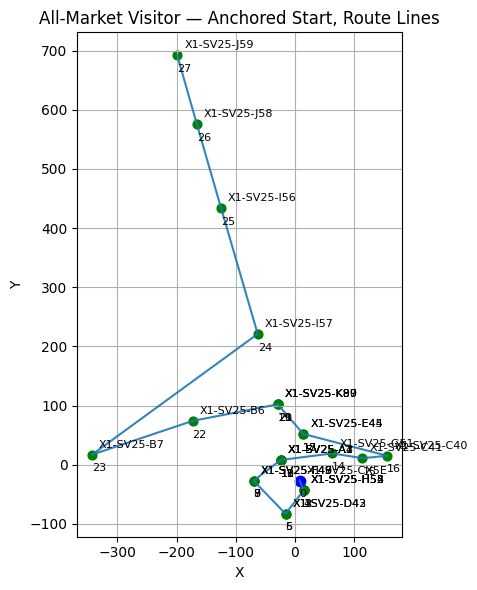

In [7]:
if __name__ == "__main__":
    
    start = nav_resp.waypoint_symbol

    route = all_market_visitor(
        markets_df= markets_df,
        start_waypoint=start,
        return_to_start=False,   # set True to draw a loop back to start
        improve_2opt=True,
        fix_start_anchor=True,   # keep chosen start as first
    )

    print(route)
    print("Total travel distance:", route["cumulative_distance"].iloc[-1])

    plot_route_svg(
        markets_df=markets_df,
        route_df=route,
        start_waypoint=start,
        svg_path="markets_route.svg",
    )

In [18]:
print(route.waypoint)
print(nav_resp.waypoint_symbol)

waypoints: List[str] = list(dict.fromkeys(route["waypoint"].astype(str).tolist()))
print(waypoints)

0      X1-SV25-G51
1      X1-SV25-C41
2      X1-SV25-C40
3      X1-SV25-E44
4      X1-SV25-E45
5       X1-SV25-A1
6       X1-SV25-A2
7       X1-SV25-A4
8       X1-SV25-A3
9     X1-SV25-CX5E
10     X1-SV25-H53
11     X1-SV25-H54
12     X1-SV25-H52
13     X1-SV25-H55
14     X1-SV25-D42
15     X1-SV25-D43
16     X1-SV25-F49
17     X1-SV25-F47
18     X1-SV25-F46
19      X1-SV25-B7
20      X1-SV25-B6
21     X1-SV25-K87
22     X1-SV25-K90
23     X1-SV25-K89
24     X1-SV25-I57
25     X1-SV25-I56
26     X1-SV25-J58
27     X1-SV25-J59
Name: waypoint, dtype: object
X1-SV25-G51
['X1-SV25-G51', 'X1-SV25-C41', 'X1-SV25-C40', 'X1-SV25-E44', 'X1-SV25-E45', 'X1-SV25-A1', 'X1-SV25-A2', 'X1-SV25-A4', 'X1-SV25-A3', 'X1-SV25-CX5E', 'X1-SV25-H53', 'X1-SV25-H54', 'X1-SV25-H52', 'X1-SV25-H55', 'X1-SV25-D42', 'X1-SV25-D43', 'X1-SV25-F49', 'X1-SV25-F47', 'X1-SV25-F46', 'X1-SV25-B7', 'X1-SV25-B6', 'X1-SV25-K87', 'X1-SV25-K90', 'X1-SV25-K89', 'X1-SV25-I57', 'X1-SV25-I56', 'X1-SV25-J58', 'X1-SV25-J59']


In [20]:
# ---------- init functions for writing to db and patrolling markets  ----------

from market_runtime import capture_market_for_waypoint
from db.auto_repo_sqlite import snapshot_many, TableSpec, upsert_many
from domain.market_rows import MarketGoodRow, MarketTransactionRow
import sqlite3

async def market_to_db(waypoint: str) -> None:
    # Fetch first (network I/O), then write to DB (short-lived connection)
    rows = await capture_market_for_waypoint(systems_api, waypoint)
    with sqlite3.connect("spacetraders.db") as conn:
        snapshot_many(conn, "market_goods", MarketGoodRow, rows["goods"])  # append-only history
        if rows["transactions"]:
            upsert_many(conn, TableSpec(table="market_transactions", pk="id"), rows["transactions"])


# --- main patrol loop ---
async def patrol_markets(ship_symbol: str, markets_df) -> None:
    # dedupe and coerce to plain list of strings
    waypoints: List[str] = list(dict.fromkeys(markets_df["waypoint"].astype(str).tolist()))
    print(waypoints)
    if not waypoints:
        print("[WARN] No waypoints to patrol.")
        return

    print(f"[PATROL] {ship_symbol} looping through {len(waypoints)} markets.")
    idx = 0
    while True:
        wp = waypoints[idx]
        try:
            print(f"[PATROL] -> Navigating to {wp} (#{idx+1}/{len(waypoints)})")
            nav_resp = await api_navigate_ship(fleet_api, ship_symbol, wp)
            print(f"[MARKET] Capturing {wp} …")
            await market_to_db(wp)
            await asyncio.sleep(1.0)  # small dwell

        except asyncio.CancelledError:
            raise
        except Exception as e:
            print(f"[ERR] Patrol step at {wp} failed: {e!r}")
            await asyncio.sleep(3.0)  # brief backoff

        # round-robin
        idx = (idx + 1) % len(waypoints)


In [ ]:
# ---------- run ----------
async def main():
    patroller = asyncio.create_task(patrol_markets(command_ship, route))
    await asyncio.gather(patroller)

await main()


['X1-SV25-G51', 'X1-SV25-C41', 'X1-SV25-C40', 'X1-SV25-E44', 'X1-SV25-E45', 'X1-SV25-A1', 'X1-SV25-A2', 'X1-SV25-A4', 'X1-SV25-A3', 'X1-SV25-CX5E', 'X1-SV25-H53', 'X1-SV25-H54', 'X1-SV25-H52', 'X1-SV25-H55', 'X1-SV25-D42', 'X1-SV25-D43', 'X1-SV25-F49', 'X1-SV25-F47', 'X1-SV25-F46', 'X1-SV25-B7', 'X1-SV25-B6', 'X1-SV25-K87', 'X1-SV25-K90', 'X1-SV25-K89', 'X1-SV25-I57', 'X1-SV25-I56', 'X1-SV25-J58', 'X1-SV25-J59']
[PATROL] KIJINIBIBI-1 looping through 28 markets.
[PATROL] -> Navigating to X1-SV25-G51 (#1/28)
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Seconds until arrival: 62.873076
Arrived and ready
[BOOT] Adapted 2 ships into fleet_object
After arriving, the status of KIJINIBIBI-1 is IN_ORBIT
Refuelling now...
Not in orbit, going into orbit now...
Prep complete
KIJINIBIBI-1  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 49.85036
Arrived and ready
[MARKET] Capturing X1-SV25-G51 …
[PATRO